In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg

# MATH 461 Unit 3 Project

**Group member**
- Ryan Hsiao
- Fanbo Feng
- Davis Li

## Numerical simulation

Calculating heat diffusion...


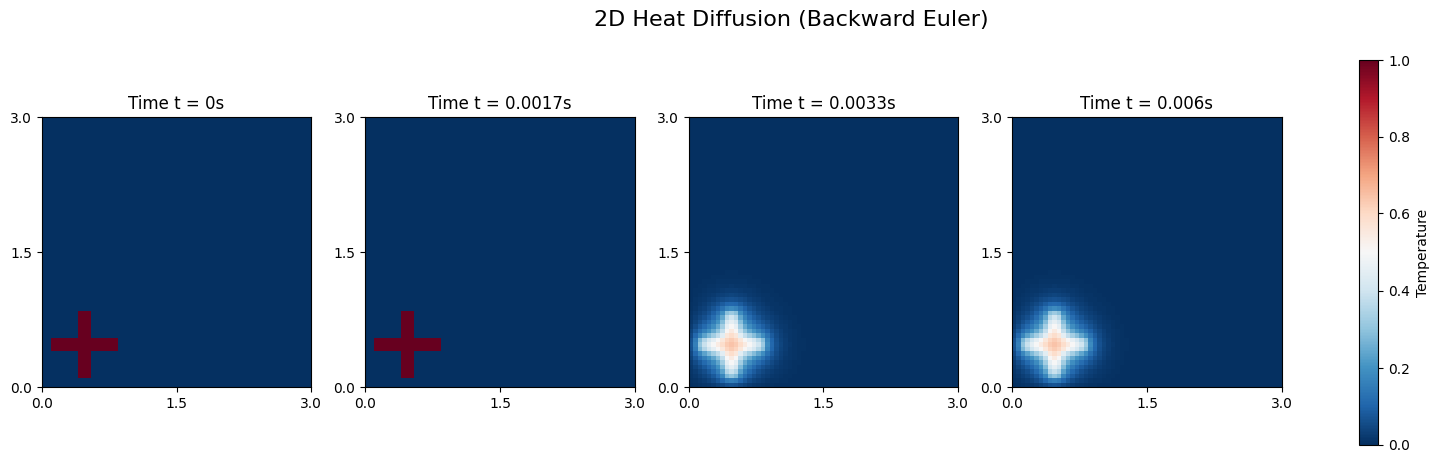

In [16]:
# The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC.

# Grid and initial condition
J = 60
h = 3.0 / J
s = np.linspace(h, 3.0, J)
k = 0.1 * h
xx, yy = np.meshgrid(s, s)
x = xx.flatten()
y = yy.flatten()

u = (((np.abs(x - 0.5) < 0.4) & (np.abs(y - 0.5) < 0.07)) | 
     ((np.abs(x - 0.5) < 0.07) & (np.abs(y - 0.5) < 0.4))).astype(float)

# Matrix Construction (Backward Euler)
N = len(s)
e = np.ones(N)
L1d = sparse.spdiags([e, -2*e, e], [-1, 0, 1], N, N).tocsr()
L1d = (3.0 / h**2) * L1d
I1d = sparse.eye(N)

L = sparse.kron(I1d, L1d) + sparse.kron(L1d, I1d)
I = sparse.eye(L.shape[0])

# Time-stepping
Tf = 4
numsteps = int(np.ceil(Tf / k))
A = I - k * L
t = 0

# Times we want to capture
target_times = [0, 0.0017, 0.0033, 0.006]
snapshots = {}

print("Calculating heat diffusion...")
for n in range(numsteps + 1):
    for target in target_times:
        if np.isclose(t, target, atol=k/2):
            snapshots[target] = u.reshape(xx.shape)
    
    if n < numsteps:
        u = linalg.spsolve(A, u)
        t += k

# Plotting with Blue-Red Colormap
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, target in enumerate(target_times):
    # 'RdBu_r' goes from Blue (low) to Red (high)
    im = axes[i].imshow(snapshots[target], extent=[0, 3, 0, 3], 
                        origin='lower', cmap='RdBu_r', vmin=0, vmax=1)
    axes[i].set_title(f'Time t = {target}s')
    axes[i].set_xticks([0, 1.5, 3])
    axes[i].set_yticks([0, 1.5, 3])

fig.colorbar(im, ax=axes.ravel().tolist(), label='Temperature')
plt.suptitle('2D Heat Diffusion (Backward Euler)', fontsize=16)
plt.show()

## Stability Analysis

Von Neumann stability analysis